# COPER to MDP States

This notebook builds a **weakly supervised interpretation head** from a trained **COPER** model to the **716 ICU-Sepsis MDP states**.

The notebook does **not** assume that bundled artifacts contain patient-level MDP state labels aligned to the MIMIC mortality benchmark sequences. They do not. Instead, the notebook does the following:

1. Load one already-trained COPER model exported by `notebooks/compare_mortality_mimic3.ipynb`.
2. Load the MIMIC mortality split stored in `MIMIC/mimic3-benchmarks/data/mortality_for_coper.data`.
3. Recompute COPER embeddings on the **train / val / test** splits using the same representation used before the mortality classifier.
4. Load the bundled ICU-Sepsis MDP from `icu_sepsis/` and sample trajectories under the bundled **expert policy**.
5. Convert those trajectories into **soft state-occupancy targets** over the 716 discrete MDP states.
6. Train a small neural network that maps each COPER embedding to a probability distribution over MDP states.

## Precise provenance

- **COPER weights / metadata** come from `code/COPER/artifacts/*.json` and, when available, `code/COPER/artifacts/*.pt` or the raw checkpoint path recorded in the JSON metadata.
- **COPER input data** come from the MIMIC mortality benchmark pickle used elsewhere in this repo: `MIMIC/mimic3-benchmarks/data/mortality_for_coper.data`.
- **MDP dynamics, expert policy, state cluster centers, and SOFA scores** come from the vendored ICU-Sepsis package assets under `code/COPER/icu_sepsis/`.

## Important limitation

This notebook learns a **trajectory-informed proxy alignment**, not a patient-level ground-truth mapping. The training target is a soft MDP-state distribution derived from sampled expert-policy trajectories and then indexed by COPER-derived risk/severity surrogates. This makes the notebook useful for **interpretation**, but it should not be read as a clinically validated patient-to-state labeling pipeline.

## Target construction used here

For each COPER embedding `z_i`, the notebook builds a target distribution `q_i(s)` over MDP states as follows:

- sample many expert-policy trajectories from the ICU-Sepsis MDP,
- compute a normalized occupancy histogram over the 716 states for each trajectory,
- stratify those trajectory histograms by terminal outcome (`death` vs `survival`) and by an MDP severity bucket based on trajectory mean SOFA,
- estimate one prototype occupancy distribution per `(outcome, severity_bucket)`,
- assign each patient a COPER severity bucket using the first principal component of the **train** embeddings,
- use the COPER mortality probability `p_i` to mix the survival and death prototypes:

`q_i(s) = (1 - p_i) * q_survival,bucket(z_i)(s) + p_i * q_death,bucket(z_i)(s)`

The small network trained below is therefore a **distillation head** from COPER latent space into a trajectory-informed MDP state distribution.


In [1]:
from __future__ import annotations

import copy
import json
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm, trange


def _resolve_bench_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "utils" / "load_coper_bundle.py").exists() and (p / "src_coper").exists():
            return p
    raise RuntimeError("Could not resolve `code/COPER` root from the current working directory.")


def _find_coper_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(12):
        if (p / "icu_sepsis" / "icu_sepsis").is_dir() and (p / "icu_sepsis" / "icu_sepsis_helpers").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError(f"Could not find COPER root containing icu_sepsis packages: start={start}")


BENCH = _resolve_bench_root()
COPER_ROOT = _find_coper_root(BENCH)
WORKSPACE = BENCH.parents[1]
PKG_ICU = COPER_ROOT / "icu_sepsis" / "icu_sepsis"
PKG_HELPERS = COPER_ROOT / "icu_sepsis" / "icu_sepsis_helpers"
for pkg in (BENCH, PKG_ICU, PKG_HELPERS):
    s = str(pkg)
    if s not in sys.path:
        sys.path.insert(0, s)

import icu_sepsis  # registers Sepsis/ICU-Sepsis-v2

from src_coper.coper_model import COPER
from src_coper.transformer_model import TRANSFORMER
from utils.coper_embed import latent_before_classifier
from utils.embedding_data_utils import load_xy_split, tensors_to_loader
from utils.load_coper_bundle import _namespace_from_hyperparams, load_meta_json


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

MORTALITY_PICKLE = WORKSPACE / "MIMIC" / "mimic3-benchmarks" / "data" / "mortality_for_coper.data"
ARTIFACTS_DIR = BENCH / "artifacts"
ENV_ID = "Sepsis/ICU-Sepsis-v2"

MODEL_CANDIDATES = [
    "coper_1node_drop0.5_s1_e3",
    "coper_1node_drop0.5_s1_e1",
    "coper_1node_drop0.5_s1",
    "coper_2node_drop0.5_s1_e3",
    "coper_2node_drop0.5_s1_e1",
    "coper_2node_drop0.5_s1",
]

EMBED_BATCH_SIZE = 256
TRAIN_BATCH_SIZE = 256
HEAD_HIDDEN_DIM = 128
HEAD_DROPOUT = 0.2
MAX_EPOCHS = 80
PATIENCE = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
N_MDP_TRAJECTORIES = 6000
MAX_TRAJ_STEPS = 80
N_SEVERITY_BUCKETS = 3

print("BENCH", BENCH)
print("COPER_ROOT", COPER_ROOT)
print("WORKSPACE", WORKSPACE)
print("DEVICE", DEVICE)
print("MORTALITY_PICKLE", MORTALITY_PICKLE)
print("ARTIFACTS_DIR", ARTIFACTS_DIR)
print("PKG_ICU", PKG_ICU)
print("PKG_HELPERS", PKG_HELPERS)


BENCH /home/charlesv/Desktop/StatisitcalGenetics/code/COPER
COPER_ROOT /home/charlesv/Desktop/StatisitcalGenetics/code/COPER
WORKSPACE /home/charlesv/Desktop/StatisitcalGenetics
DEVICE cuda
MORTALITY_PICKLE /home/charlesv/Desktop/StatisitcalGenetics/MIMIC/mimic3-benchmarks/data/mortality_for_coper.data
ARTIFACTS_DIR /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts
PKG_ICU /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/icu_sepsis/icu_sepsis
PKG_HELPERS /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/icu_sepsis/icu_sepsis_helpers


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Model loading

This notebook tries to load a trained COPER model in the following order:

1. a portable export bundle `artifacts/<name>.pt`, if it exists,
2. otherwise the raw checkpoint path recorded in `artifacts/<name>.json` under `source_checkpoint`.

The JSON file is the authoritative source for the hyperparameters needed to reconstruct the network architecture. This is the same metadata written by `utils/export_coper_checkpoint.py` after `notebooks/compare_mortality_mimic3.ipynb` trains and exports a model.

If neither the exported `.pt` bundle nor the raw checkpoint exists locally, the notebook stops with a precise error message. That is intentional: the JSON metadata alone is not sufficient to run inference without weights.


In [2]:
def _instantiate_model_from_meta(meta: dict, state_dict: dict[str, torch.Tensor], device: torch.device):
    h = meta["hyperparams"]
    args = _namespace_from_hyperparams(h)
    if any(str(k).startswith("ode_out.") for k in state_dict.keys()):
        args.second_node = True

    model_type = str(h.get("model_type", "COPER")).upper()
    model_cls = TRANSFORMER if model_type == "TRANSFORMER" else COPER
    model = model_cls(
        args,
        1,
        h.get("input_size_mimic", 76),
        args.num_latents,
        args.latent_dim,
        args.rec_layers,
        args.units,
        nn.Tanh,
        args.cont_in,
        args.cont_out,
        emb_dim=args.emb_dim,
        device=device,
    ).to(device)
    model.load_state_dict(state_dict, strict=True)
    model.eval()
    return model


def _load_state_dict(weight_path: Path, device: torch.device) -> dict[str, torch.Tensor]:
    raw = torch.load(weight_path, map_location=device)
    if isinstance(raw, dict) and "model_state_dict" in raw:
        return raw["model_state_dict"]
    if isinstance(raw, dict) and "state_dict" in raw:
        return raw["state_dict"]
    return raw


def resolve_model(candidates: list[str]):
    attempted = []
    for stem in candidates:
        json_path = ARTIFACTS_DIR / f"{stem}.json"
        pt_path = ARTIFACTS_DIR / f"{stem}.pt"
        if not json_path.is_file():
            attempted.append({"stem": stem, "reason": f"missing metadata {json_path}"})
            continue

        meta = load_meta_json(json_path)
        ckpt_path = Path(meta.get("source_checkpoint", ""))
        weight_path = None
        if pt_path.is_file():
            weight_path = pt_path
        elif ckpt_path.is_file():
            weight_path = ckpt_path

        if weight_path is None:
            attempted.append(
                {
                    "stem": stem,
                    "reason": "metadata exists but neither exported bundle nor raw checkpoint exists locally",
                    "json": str(json_path),
                    "expected_bundle": str(pt_path),
                    "expected_checkpoint": str(ckpt_path),
                }
            )
            continue

        state_dict = _load_state_dict(weight_path, DEVICE)
        model = _instantiate_model_from_meta(meta, state_dict, DEVICE)
        return {
            "stem": stem,
            "json_path": json_path,
            "weight_path": weight_path,
            "meta": meta,
            "model": model,
            "attempted": attempted,
        }

    raise FileNotFoundError(
        "Could not locate usable COPER weights. Check the attempted candidates below and re-run "
        "`notebooks/compare_mortality_mimic3.ipynb` / `utils/export_coper_checkpoint.py` if needed.\n"
        + json.dumps(attempted, indent=2)
    )


assert ARTIFACTS_DIR.is_dir(), ARTIFACTS_DIR
assert MORTALITY_PICKLE.is_file(), MORTALITY_PICKLE

MODEL_INFO = resolve_model(MODEL_CANDIDATES)
MODEL = MODEL_INFO["model"]
MODEL_META = MODEL_INFO["meta"]

print("Selected model stem:", MODEL_INFO["stem"])
print("Metadata JSON:", MODEL_INFO["json_path"])
print("Weights loaded from:", MODEL_INFO["weight_path"])
print(json.dumps(MODEL_META["hyperparams"], indent=2))


Selected model stem: coper_1node_drop0.5_s1_e3
Metadata JSON: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts/coper_1node_drop0.5_s1_e3.json
Weights loaded from: /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts/coper_1node_drop0.5_s1_e3.pt
{
  "model_type": "COPER",
  "dataset": "mimic",
  "fold": -1,
  "drop": 0.5,
  "random_seed": 1,
  "num_latents": 48,
  "latent_dim": 64,
  "rec_layers": 3,
  "units": 128,
  "emb_dim": 32,
  "self_per_cross_attn": 1,
  "latent_heads": 2,
  "cross_heads": 1,
  "cross_dim_head": 128,
  "latent_dim_head": 128,
  "ff_dropout": 0.5,
  "att_dropout": 0.5,
  "ode_dropout": 0.5,
  "cont_in": true,
  "cont_out": false,
  "second_node": false,
  "seq_len": 48,
  "input_size_mimic": 76
}


## Embedding extraction on the benchmark splits

The COPER embedding used here is the same one used in the repo's embedding utilities: the representation **after** the optional input ODE, Perceiver, optional output ODE, and LayerNorm, but **before** the mortality classifier. For COPER this is the final latent slice returned by `utils.coper_embed.latent_before_classifier`.

The splits below come directly from `mortality_for_coper.data` via `utils.embedding_data_utils.load_xy_split`:

- `train`
- `val`
- `test`

The notebook does **not** reshuffle those benchmark splits. They remain the official split used for the COPER mortality task. The small MDP head is trained on the COPER **train** embeddings, early-stopped on **val**, and reported on **test**.


In [3]:
@torch.no_grad()
def extract_split_embeddings(split: str, max_samples: int | None = None):
    X_np, y_np = load_xy_split(MORTALITY_PICKLE, split)
    loader = tensors_to_loader(
        X_np,
        y_np,
        max_samples=max_samples,
        batch_size=EMBED_BATCH_SIZE,
        random_state=RANDOM_STATE,
        device=DEVICE,
    )

    zs, ps, ys = [], [], []
    for batch in tqdm(loader, desc=f"embeddings:{split}"):
        x = batch["X"]
        y = batch["y"].reshape(-1)
        tp = batch["tp"][0]

        z = latent_before_classifier(MODEL, x, [tp], [tp], [tp]).detach().cpu()
        p = MODEL(x, [tp], [tp], [tp]).reshape(-1).detach().cpu()

        zs.append(z)
        ps.append(p)
        ys.append(y.detach().cpu())

    out = {
        "z": torch.cat(zs, dim=0).float(),
        "p_mortality": torch.cat(ps, dim=0).float().clamp(1e-4, 1 - 1e-4),
        "y": torch.cat(ys, dim=0).float(),
    }
    return out


split_data = {
    split: extract_split_embeddings(split)
    for split in ["train", "val", "test"]
}

split_summary = pd.DataFrame(
    {
        split: {
            "n": int(v["z"].shape[0]),
            "embedding_dim": int(v["z"].shape[1]),
            "mean_mortality_prob": float(v["p_mortality"].mean()),
            "mortality_rate": float(v["y"].mean()),
        }
        for split, v in split_data.items()
    }
).T
split_summary

embeddings:test: 100%|██████████| 13/13 [00:00<00:00, 15.82it/s]


,n,embedding_dim,mean_mortality_prob,mortality_rate
train,14681.0,64.0,0.116306,0.135345
val,3222.0,64.0,0.118373,0.135320
test,3236.0,64.0,0.115777,0.115575


## MDP trajectory targets

The bundled ICU-Sepsis environment provides:

- a discrete state space of size `716`,
- a discrete action space of size `25`,
- an expert policy `pi(a|s)`,
- a `47`-dimensional cluster center vector for each MDP state,
- a SOFA score summary for each state.

This notebook samples trajectories from the bundled environment using the bundled expert policy. For each simulated trajectory it computes:

- the sequence of visited states,
- the terminal outcome (`death` or `survival`; other terminal cases are dropped from prototype estimation),
- the mean SOFA score across the visited states,
- a normalized occupancy histogram over the 716 states.

Those histograms are then averaged into prototype distributions grouped by:

- `outcome in {death, survival}`
- `severity_bucket in {0, 1, 2}`

where `severity_bucket` is defined by tertiles of the trajectory mean SOFA.

The patient-side severity bucket is intentionally simple and reproducible: it is the tertile of the first PCA component of the **train** COPER embeddings, then applied unchanged to `val` and `test`.


In [4]:
ENV_ID = "Sepsis/ICU-Sepsis-v2"
env = gym.make(ENV_ID)
mdp = env.unwrapped
expert_pi = np.asarray(mdp.expert_policy, dtype=np.float64)
sofa_scores = np.asarray(mdp.sofa_scores, dtype=np.float32).reshape(-1)
num_states = int(mdp.num_states)
num_actions = int(mdp.num_actions)

print("num_states", num_states)
print("num_actions", num_actions)
print("state_cluster_centers", np.asarray(mdp.state_cluster_centers).shape)


def rollout_expert(seed: int, max_steps: int = MAX_TRAJ_STEPS):
    rng = np.random.default_rng(seed)
    obs, info = env.reset(seed=int(seed))

    states = [int(obs)]
    sofas = [float(info["sofa_score"])]
    rewards = []

    for _ in range(max_steps):
        probs = expert_pi[obs].astype(np.float64)
        probs = probs / probs.sum()
        action = int(rng.choice(num_actions, p=probs))
        obs, reward, terminated, truncated, info = env.step(action)
        states.append(int(obs))
        sofas.append(float(info["sofa_score"]))
        rewards.append(float(reward))
        if terminated or truncated:
            break

    occ = np.bincount(states, minlength=num_states).astype(np.float32)
    occ /= np.maximum(occ.sum(), 1.0)
    terminal_state = int(states[-1])
    if terminal_state == 713:
        outcome = "death"
    elif terminal_state == 714:
        outcome = "survival"
    else:
        outcome = "other"

    return {
        "states": states,
        "occupancy": occ,
        "mean_sofa": float(np.mean(sofas)),
        "terminal_state": terminal_state,
        "outcome": outcome,
        "return": float(np.sum(rewards)),
        "length": len(states) - 1,
    }


traj_rows = []
occupancies = []
for i in trange(N_MDP_TRAJECTORIES, desc="sampling expert MDP trajectories"):
    tr = rollout_expert(seed=RANDOM_STATE + i)
    if tr["outcome"] == "other":
        continue
    traj_rows.append({k: v for k, v in tr.items() if k != "occupancy" and k != "states"})
    occupancies.append(tr["occupancy"])

traj_df = pd.DataFrame(traj_rows)
traj_occ = np.stack(occupancies, axis=0)
assert traj_occ.shape[1] == num_states

sofa_bins = np.quantile(traj_df["mean_sofa"], np.linspace(0, 1, N_SEVERITY_BUCKETS + 1)[1:-1])
traj_df["severity_bucket"] = np.digitize(traj_df["mean_sofa"].to_numpy(), bins=sofa_bins, right=False)

prototype_targets: dict[tuple[str, int], np.ndarray] = {}
prototype_summary_rows = []
for outcome in ["survival", "death"]:
    mask_outcome = traj_df["outcome"].eq(outcome).to_numpy()
    global_proto = traj_occ[mask_outcome].mean(axis=0)
    global_proto = np.clip(global_proto, 1e-8, None)
    global_proto /= global_proto.sum()

    for bucket in range(N_SEVERITY_BUCKETS):
        mask = mask_outcome & traj_df["severity_bucket"].eq(bucket).to_numpy()
        proto = traj_occ[mask].mean(axis=0) if mask.any() else global_proto.copy()
        proto = np.clip(proto, 1e-8, None)
        proto /= proto.sum()
        prototype_targets[(outcome, bucket)] = proto.astype(np.float32)
        prototype_summary_rows.append(
            {
                "outcome": outcome,
                "severity_bucket": bucket,
                "n_trajectories": int(mask.sum()),
                "mean_sofa": float(traj_df.loc[mask, "mean_sofa"].mean()) if mask.any() else np.nan,
                "mean_length": float(traj_df.loc[mask, "length"].mean()) if mask.any() else np.nan,
            }
        )

prototype_summary = pd.DataFrame(prototype_summary_rows)
display(traj_df.groupby("outcome")[["length", "mean_sofa", "return"]].mean())
prototype_summary


pca = PCA(n_components=1, random_state=RANDOM_STATE)
train_pc1 = pca.fit_transform(split_data["train"]["z"].numpy()).reshape(-1)
patient_bins = np.quantile(train_pc1, np.linspace(0, 1, N_SEVERITY_BUCKETS + 1)[1:-1])


def patient_severity_bucket(z: torch.Tensor) -> np.ndarray:
    pc1 = pca.transform(z.numpy()).reshape(-1)
    return np.digitize(pc1, bins=patient_bins, right=False)


def build_soft_targets(z: torch.Tensor, p_mortality: torch.Tensor) -> torch.Tensor:
    buckets = patient_severity_bucket(z)
    p = p_mortality.numpy().reshape(-1, 1).astype(np.float32)
    q_survive = np.stack([prototype_targets[("survival", int(b))] for b in buckets], axis=0)
    q_death = np.stack([prototype_targets[("death", int(b))] for b in buckets], axis=0)
    q = (1.0 - p) * q_survive + p * q_death
    q = q / np.clip(q.sum(axis=1, keepdims=True), 1e-8, None)
    return torch.from_numpy(q.astype(np.float32))


for split, values in split_data.items():
    values["q_target"] = build_soft_targets(values["z"], values["p_mortality"])
    values["severity_bucket"] = torch.from_numpy(patient_severity_bucket(values["z"]).astype(np.int64))

pd.DataFrame(
    {
        split: {
            "target_entropy": float((-(v["q_target"] * v["q_target"].log()).sum(dim=1)).mean()),
            "mean_bucket": float(v["severity_bucket"].float().mean()),
        }
        for split, v in split_data.items()
    }
).T

num_states 716
num_actions 25
state_cluster_centers (716, 47)


sampling expert MDP trajectories: 100%|██████████| 6000/6000 [00:01<00:00, 4149.18it/s]


,length,mean_sofa,return
outcome,,,
death,8.566052,5.566587,0.0
survival,9.076432,4.984548,1.0


,target_entropy,mean_bucket
train,5.487961,1.000000
val,5.475327,0.982309
test,5.479412,0.987948


## Train a small network from embedding to state distribution

The model below is intentionally small: a two-layer MLP ending in `716` logits, followed by a softmax at evaluation time.

### Input

- COPER embedding `z_i`

### Target

- soft MDP-state distribution `q_i(s)` defined above

### Loss

- soft cross-entropy: `- sum_s q_i(s) log p_theta(s | z_i)`

### Split discipline

- fit the head on **train** only,
- use **val** for early stopping,
- report the final metrics on **test**.

This keeps the COPER benchmark split intact even though the teacher targets are weakly supervised.


In [5]:
class StateDistributionHead(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def make_loader(split: str, shuffle: bool) -> DataLoader:
    values = split_data[split]
    ds = TensorDataset(values["z"], values["q_target"], values["y"], values["p_mortality"])
    return DataLoader(ds, batch_size=TRAIN_BATCH_SIZE, shuffle=shuffle)


def soft_cross_entropy(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    log_probs = F.log_softmax(logits, dim=-1)
    return -(targets * log_probs).sum(dim=-1).mean()


train_loader = make_loader("train", shuffle=True)
val_loader = make_loader("val", shuffle=False)
test_loader = make_loader("test", shuffle=False)

head = StateDistributionHead(
    in_dim=int(split_data["train"]["z"].shape[1]),
    hidden_dim=HEAD_HIDDEN_DIM,
    out_dim=num_states,
    dropout=HEAD_DROPOUT,
).to(DEVICE)
optimizer = torch.optim.AdamW(head.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

history = []
best_state = None
best_val = float("inf")
bad_epochs = 0

for epoch in range(1, MAX_EPOCHS + 1):
    head.train()
    train_losses = []
    for z, q, _, _ in train_loader:
        z = z.to(DEVICE)
        q = q.to(DEVICE)
        optimizer.zero_grad()
        logits = head(z)
        loss = soft_cross_entropy(logits, q)
        loss.backward()
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    head.eval()
    with torch.no_grad():
        val_losses = []
        for z, q, _, _ in val_loader:
            z = z.to(DEVICE)
            q = q.to(DEVICE)
            logits = head(z)
            val_losses.append(float(soft_cross_entropy(logits, q).cpu()))

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

    if val_loss < best_val - 1e-5:
        best_val = val_loss
        best_state = copy.deepcopy(head.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch={epoch:03d} train_loss={train_loss:.6f} val_loss={val_loss:.6f}")

    if bad_epochs >= PATIENCE:
        print(f"Early stop at epoch {epoch} (best val={best_val:.6f})")
        break

assert best_state is not None
head.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df.tail()

epoch=001 train_loss=5.871428 val_loss=5.580166
epoch=005 train_loss=5.536967 val_loss=5.497494
epoch=010 train_loss=5.517863 val_loss=5.487994
epoch=015 train_loss=5.510187 val_loss=5.484697
epoch=020 train_loss=5.506102 val_loss=5.483031
epoch=025 train_loss=5.503056 val_loss=5.482626
epoch=030 train_loss=5.502400 val_loss=5.483764
epoch=035 train_loss=5.500413 val_loss=5.482034
epoch=040 train_loss=5.499546 val_loss=5.480881
epoch=045 train_loss=5.498264 val_loss=5.482374
epoch=050 train_loss=5.498889 val_loss=5.481003
epoch=055 train_loss=5.497433 val_loss=5.482871
epoch=060 train_loss=5.497345 val_loss=5.481350
epoch=065 train_loss=5.497163 val_loss=5.481474
Early stop at epoch 68 (best val=5.479963)


,epoch,train_loss,val_loss
63,64,5.497119,5.480505
64,65,5.497163,5.481474
65,66,5.496585,5.480453
66,67,5.496700,5.480450
67,68,5.496119,5.482241


In [6]:
@torch.no_grad()
def evaluate_split(split: str) -> dict:
    loader = make_loader(split, shuffle=False)
    losses = []
    preds = []
    ys = []
    mort = []

    head.eval()
    for z, q, y, p_mort in loader:
        z = z.to(DEVICE)
        q = q.to(DEVICE)
        logits = head(z)
        probs = torch.softmax(logits, dim=-1).cpu()
        losses.append(float(soft_cross_entropy(logits, q).cpu()))
        preds.append(probs)
        ys.append(y)
        mort.append(p_mort)

    pred = torch.cat(preds, dim=0)
    y = torch.cat(ys, dim=0)
    p_mort = torch.cat(mort, dim=0)
    exp_sofa = pred @ torch.from_numpy(sofa_scores)
    pred_entropy = -(pred * pred.clamp_min(1e-8).log()).sum(dim=1)
    top_state = pred.argmax(dim=1)

    return {
        "split": split,
        "loss": float(np.mean(losses)),
        "pred": pred,
        "y": y,
        "p_mortality": p_mort,
        "expected_sofa": exp_sofa,
        "pred_entropy": pred_entropy,
        "top_state": top_state,
    }


metrics = {split: evaluate_split(split) for split in ["train", "val", "test"]}
metrics_df = pd.DataFrame(
    {
        split: {
            "soft_xent": values["loss"],
            "mean_expected_sofa": float(values["expected_sofa"].mean()),
            "mean_pred_entropy": float(values["pred_entropy"].mean()),
            "mean_top_state": float(values["top_state"].float().mean()),
        }
        for split, values in metrics.items()
    }
).T

test_analysis = pd.DataFrame(
    {
        "mortality_label": metrics["test"]["y"].numpy(),
        "coper_p_mortality": metrics["test"]["p_mortality"].numpy(),
        "expected_sofa": metrics["test"]["expected_sofa"].numpy(),
        "pred_entropy": metrics["test"]["pred_entropy"].numpy(),
        "top_state": metrics["test"]["top_state"].numpy(),
        "top_state_sofa": sofa_scores[metrics["test"]["top_state"].numpy()],
    }
)

state_mass = metrics["test"]["pred"].mean(dim=0).numpy()
state_rank = np.argsort(-state_mass)[:15]
state_rank_df = pd.DataFrame(
    {
        "state": state_rank,
        "mean_pred_mass": state_mass[state_rank],
        "sofa": sofa_scores[state_rank],
    }
)

HEAD_OUT = ARTIFACTS_DIR / f"{MODEL_INFO['stem']}_to_mdp_states_head.pt"
torch.save(
    {
        "head_state_dict": head.state_dict(),
        "model_stem": MODEL_INFO["stem"],
        "source_weights": str(MODEL_INFO["weight_path"]),
        "source_meta_json": str(MODEL_INFO["json_path"]),
        "sofa_bins": sofa_bins,
        "patient_bins": patient_bins,
        "history": history,
    },
    HEAD_OUT,
)

print("Saved head to", HEAD_OUT)
display(history_df.tail())
display(metrics_df)
display(test_analysis.groupby("mortality_label")[["coper_p_mortality", "expected_sofa", "pred_entropy", "top_state_sofa"]].mean())
display(state_rank_df)


Saved head to /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts/coper_1node_drop0.5_s1_e3_to_mdp_states_head.pt


,epoch,train_loss,val_loss
63,64,5.497119,5.480505
64,65,5.497163,5.481474
65,66,5.496585,5.480453
66,67,5.496700,5.480450
67,68,5.496119,5.482241


,soft_xent,mean_expected_sofa,mean_pred_entropy,mean_top_state
train,5.491229,5.100429,5.51019,713.986633
val,5.479963,5.074298,5.49848,713.986633
test,5.484215,5.080795,5.50174,713.989197


,coper_p_mortality,expected_sofa,pred_entropy,top_state_sofa
mortality_label,,,,
0.0,0.099058,5.216524,5.547661,0.0
1.0,0.243715,4.042145,5.150327,0.0


,state,mean_pred_mass,sofa
0,714,0.169132,0.000000
1,713,0.029974,0.000000
2,222,0.006178,6.788779
3,145,0.005342,7.676417
4,339,0.004999,9.156935
5,301,0.004996,6.791536
6,56,0.004597,6.522727
7,76,0.003753,7.466523
8,80,0.003723,11.228169
9,103,0.003709,8.228856


## How to read the outputs

- `soft_xent` is the distillation loss against the trajectory-derived soft targets.
- `expected_sofa` is the average SOFA score under the predicted state distribution: `sum_s p_theta(s|z) * SOFA(s)`.
- `pred_entropy` measures how concentrated the predicted state distribution is.
- `top_state` is the single most likely MDP state under the head.

A useful sanity check is whether higher COPER mortality risk corresponds to higher predicted `expected_sofa` and to top states with higher MDP SOFA. If that pattern is absent, the interpretation head is probably not learning a clinically coherent alignment.

## What this notebook is good for

- a first, fully notebook-contained bridge from COPER embeddings to the ICU-Sepsis MDP,
- generating interpretable state distributions from already-trained COPER models,
- checking whether COPER latent geometry tracks coarse MDP severity structure.

## What this notebook is not

- not a ground-truth patient-level mapping,
- not a reconstruction of the original AI Clinician state assignment pipeline,
- not a substitute for a true aligned dataset with patient-timepoint MDP labels.


## Visualizing the mapping on individual validation / test patients

The cells below add a patient-level visualization layer on top of the trained head.

For a selected patient from `val` or `test`, the notebook shows:

1. the patient location in a 2D PCA view of the COPER embedding space,
2. the head prediction `p_theta(s | z)` displayed as a density over the 716 MDP states,
3. a **reference expert-policy trajectory** sampled from the ICU-Sepsis MDP and chosen to be close to that patient's weak target distribution.

### Important interpretation note

The plotted trajectory is **not the patient's real trajectory**. This notebook does not have patient-level MDP state labels aligned to the COPER mortality benchmark. The trajectory shown here is therefore a **proxy / reference trajectory** from the bundled MDP, selected to match the patient's outcome bucket and to be close to the patient's weak target distribution or predicted density.

This is still useful for interpretation: it lets you visually compare

- where the patient's COPER embedding sits,
- which MDP states receive high mass under the learned head,
- what a representative MDP trajectory looks like in that same region of the state space.


In [7]:
import matplotlib.pyplot as plt


embedding_pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
embedding_xy_train = embedding_pca2.fit_transform(split_data["train"]["z"].numpy())
embedding_xy = {
    "train": embedding_xy_train,
    "val": embedding_pca2.transform(split_data["val"]["z"].numpy()),
    "test": embedding_pca2.transform(split_data["test"]["z"].numpy()),
}

state_centers = np.asarray(mdp.state_cluster_centers, dtype=np.float32)
state_pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
state_xy = state_pca2.fit_transform(state_centers)


def _soft_cross_entropy_np(q: np.ndarray, p: np.ndarray) -> float:
    return float(-(q * np.log(np.clip(p, 1e-8, None))).sum())


def _bucket_for_patient(split: str, idx: int) -> int:
    return int(split_data[split]["severity_bucket"][idx].item())


def _outcome_name_from_label(y_value: float) -> str:
    return "death" if float(y_value) >= 0.5 else "survival"


def _sample_reference_trajectories(outcome: str, bucket: int, n_keep: int = 48, max_tries: int = 4000, seed0: int = 100_000):
    rows = []
    tries = 0
    while len(rows) < n_keep and tries < max_tries:
        tr = rollout_expert(seed=seed0 + tries)
        tries += 1
        if tr["outcome"] != outcome:
            continue
        tr_bucket = int(np.digitize([tr["mean_sofa"]], bins=sofa_bins, right=False)[0])
        if tr_bucket != bucket:
            continue
        rows.append(tr)
    return rows


def _select_reference_trajectory(target_dist: np.ndarray, outcome: str, bucket: int):
    candidates = _sample_reference_trajectories(outcome=outcome, bucket=bucket)
    if not candidates:
        return None
    scores = [
        np.linalg.norm(tr["occupancy"] - target_dist) + 0.10 * _soft_cross_entropy_np(target_dist, np.clip(tr["occupancy"], 1e-8, None))
        for tr in candidates
    ]
    return candidates[int(np.argmin(scores))]


def _plot_state_density(ax, density: np.ndarray, title: str, trajectory_states: list[int] | None = None, top_k: int = 12):
    density = np.asarray(density, dtype=np.float64)
    density = density / density.sum()
    sc = ax.scatter(
        state_xy[:, 0],
        state_xy[:, 1],
        c=density,
        cmap="viridis",
        s=18 + 1800 * density,
        alpha=0.85,
        linewidths=0,
    )
    top_idx = np.argsort(-density)[:top_k]
    ax.scatter(
        state_xy[top_idx, 0],
        state_xy[top_idx, 1],
        facecolors="none",
        edgecolors="white",
        s=60,
        linewidths=0.8,
    )
    if trajectory_states is not None and len(trajectory_states) > 0:
        coords = state_xy[np.asarray(trajectory_states, dtype=int)]
        ax.plot(coords[:, 0], coords[:, 1], "-o", color="tomato", lw=1.5, ms=3, alpha=0.9)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return sc


def visualize_patient_mapping(split: str, idx: int, compare_to: str = "target"):
    assert split in {"val", "test"}
    pred = metrics[split]["pred"][idx].numpy()
    target = split_data[split]["q_target"][idx].numpy()
    z_xy = embedding_xy[split][idx]
    y_true = float(split_data[split]["y"][idx].item())
    p_mort = float(split_data[split]["p_mortality"][idx].item())
    bucket = _bucket_for_patient(split, idx)
    outcome_name = _outcome_name_from_label(y_true)
    ref = _select_reference_trajectory(target if compare_to == "target" else pred, outcome=outcome_name, bucket=bucket)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    bg = embedding_xy[split]
    axes[0].scatter(bg[:, 0], bg[:, 1], s=8, c=split_data[split]["y"].numpy(), cmap="coolwarm", alpha=0.20)
    axes[0].scatter([z_xy[0]], [z_xy[1]], s=220, c=[p_mort], cmap="magma", vmin=0, vmax=1, edgecolors="black", linewidths=1.2)
    axes[0].set_title(f"{split} embedding PCA\nidx={idx} y={int(y_true)} p_mort={p_mort:.3f}")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    sc1 = _plot_state_density(axes[1], pred, title="Head density p(state|z)")
    sc2 = _plot_state_density(axes[2], target, title="Weak target q_target")

    if ref is not None:
        sc3 = _plot_state_density(
            axes[3],
            ref["occupancy"],
            title=f"Reference trajectory\n{outcome_name}, bucket={bucket}, len={ref['length']}",
            trajectory_states=ref["states"],
        )
    else:
        sc3 = _plot_state_density(axes[3], target, title="Reference trajectory unavailable")

    fig.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)
    fig.colorbar(sc2, ax=axes[2], fraction=0.046, pad=0.04)
    fig.colorbar(sc3, ax=axes[3], fraction=0.046, pad=0.04)
    plt.tight_layout()

    summary = pd.DataFrame(
        [
            {
                "split": split,
                "idx": idx,
                "mortality_label": int(y_true),
                "coper_p_mortality": p_mort,
                "severity_bucket": bucket,
                "pred_expected_sofa": float((metrics[split]["pred"][idx] * torch.from_numpy(sofa_scores)).sum().item()),
                "target_entropy": float(-(split_data[split]["q_target"][idx] * split_data[split]["q_target"][idx].clamp_min(1e-8).log()).sum().item()),
                "pred_entropy": float(-(metrics[split]["pred"][idx] * metrics[split]["pred"][idx].clamp_min(1e-8).log()).sum().item()),
                "top_state_pred": int(metrics[split]["top_state"][idx].item()),
                "top_state_sofa": float(sofa_scores[int(metrics[split]["top_state"][idx].item())]),
                "reference_found": ref is not None,
                "reference_terminal_state": None if ref is None else int(ref["terminal_state"]),
                "reference_mean_sofa": None if ref is None else float(ref["mean_sofa"]),
                "reference_length": None if ref is None else int(ref["length"]),
            }
        ]
    )
    display(summary)
    return fig, summary, ref


In [8]:
def pick_interesting_indices(split: str, n_each: int = 2) -> list[int]:
    p = split_data[split]["p_mortality"].numpy()
    y = split_data[split]["y"].numpy()
    chosen = []
    for target_label in [0.0, 1.0]:
        mask = np.where(y == target_label)[0]
        if len(mask) == 0:
            continue
        order_low = mask[np.argsort(p[mask])[:n_each]]
        order_high = mask[np.argsort(-p[mask])[:n_each]]
        chosen.extend(order_low.tolist())
        chosen.extend(order_high.tolist())
    return sorted(set(chosen))[: max(4, 2 * n_each)]


examples = {
    "val": pick_interesting_indices("val", n_each=1),
    "test": pick_interesting_indices("test", n_each=1),
}
examples


{'val': [63, 1296, 1405, 2139], 'test': [208, 1471, 1700, 3194]}


### VAL examples


,split,idx,mortality_label,coper_p_mortality,severity_bucket,pred_expected_sofa,target_entropy,pred_entropy,top_state_pred,top_state_sofa,reference_found,reference_terminal_state,reference_mean_sofa,reference_length
0,val,63,1,0.023859,2,6.773004,5.838902,5.849035,714,0.0,True,713,5.659306,43


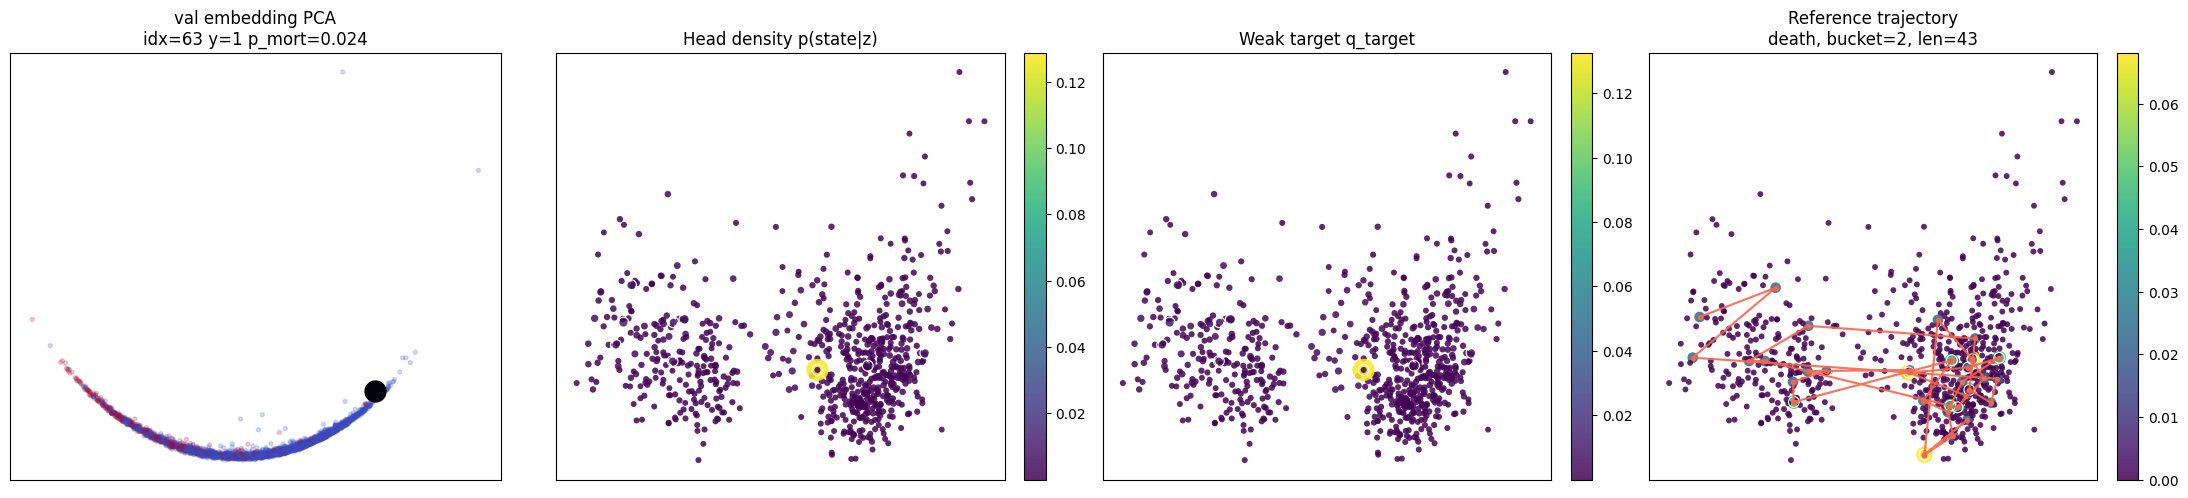

,split,idx,mortality_label,coper_p_mortality,severity_bucket,pred_expected_sofa,target_entropy,pred_entropy,top_state_pred,top_state_sofa,reference_found,reference_terminal_state,reference_mean_sofa,reference_length
0,val,1296,0,0.708012,0,3.554352,4.804724,4.828351,713,0.0,True,714,4.276856,31


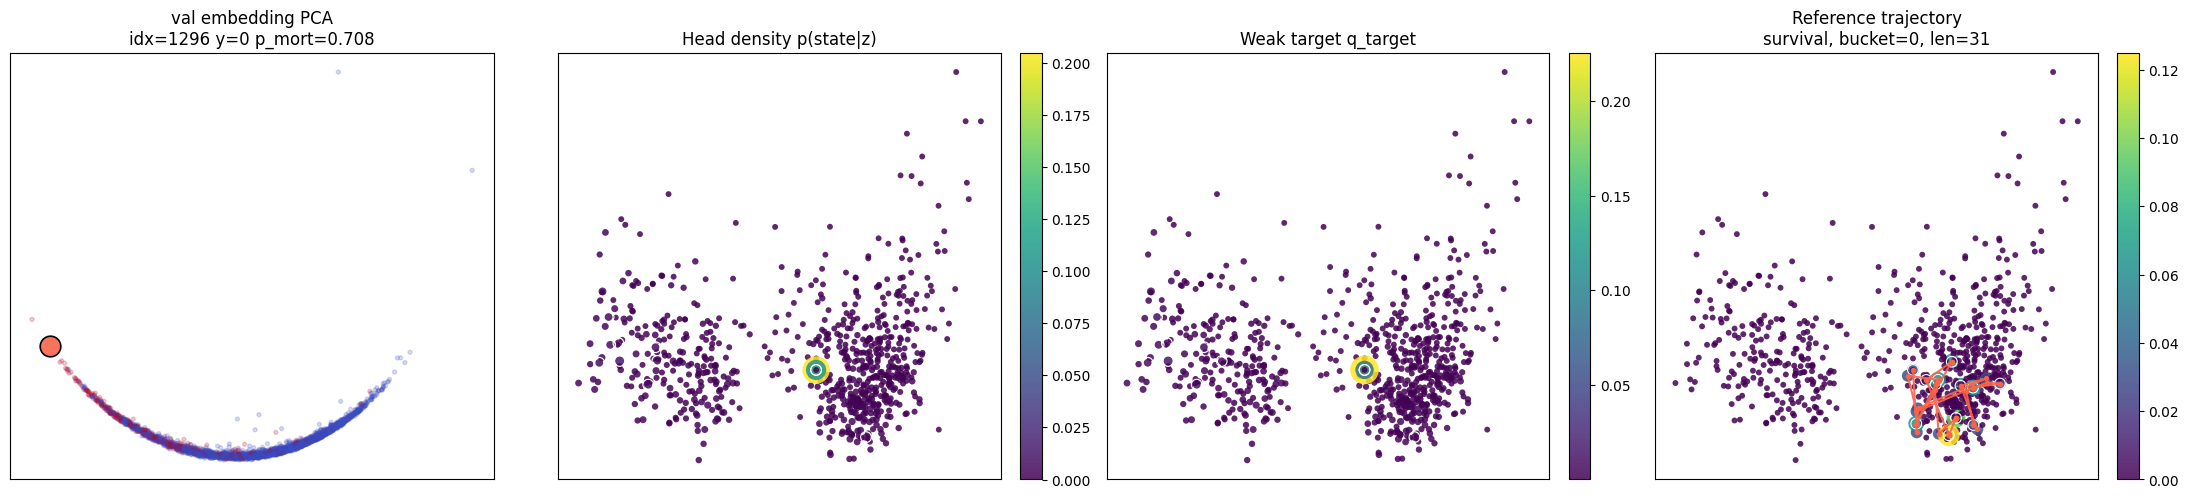

,split,idx,mortality_label,coper_p_mortality,severity_bucket,pred_expected_sofa,target_entropy,pred_entropy,top_state_pred,top_state_sofa,reference_found,reference_terminal_state,reference_mean_sofa,reference_length
0,val,1405,0,0.017397,2,6.867053,5.835178,5.916243,714,0.0,True,714,7.411487,24


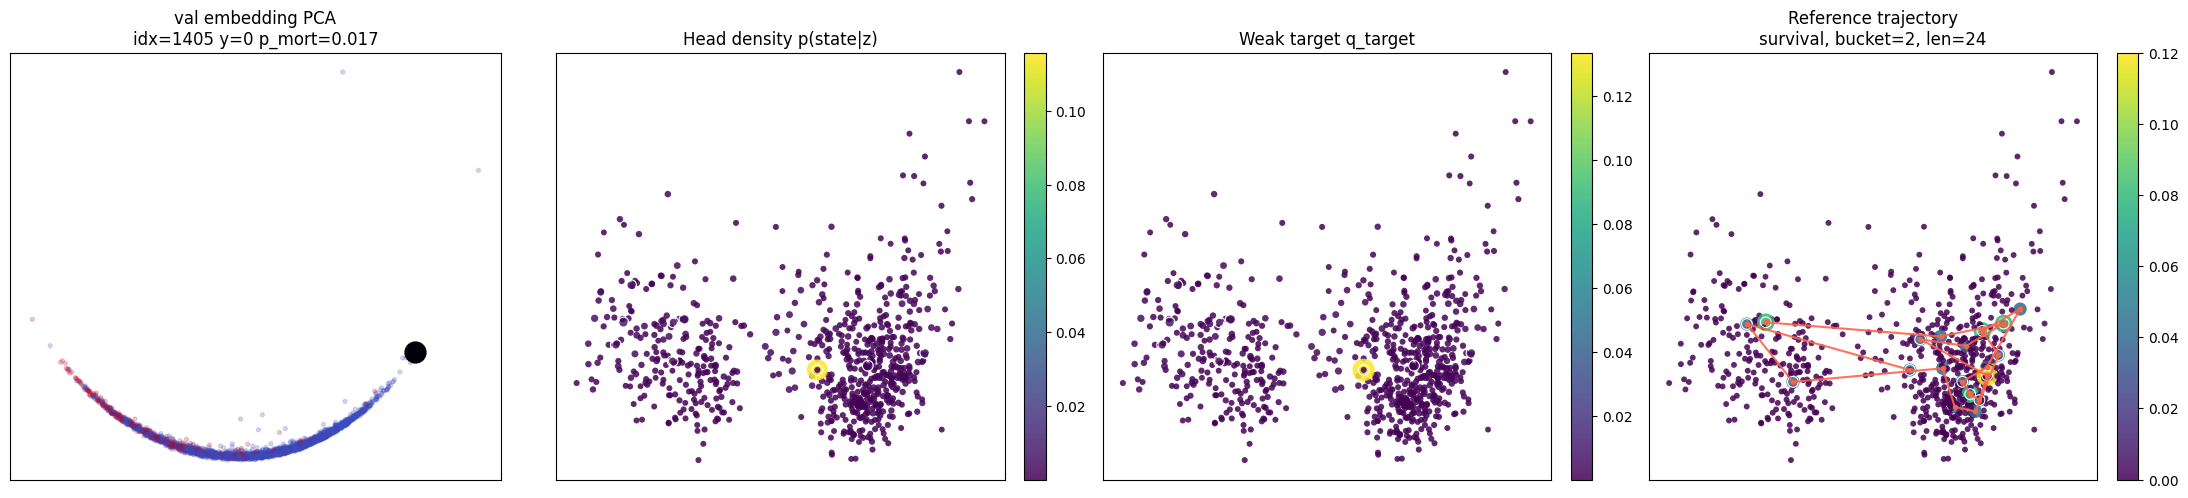

,split,idx,mortality_label,coper_p_mortality,severity_bucket,pred_expected_sofa,target_entropy,pred_entropy,top_state_pred,top_state_sofa,reference_found,reference_terminal_state,reference_mean_sofa,reference_length
0,val,2139,1,0.781572,0,3.509002,4.747819,4.751276,713,0.0,True,713,4.218156,64


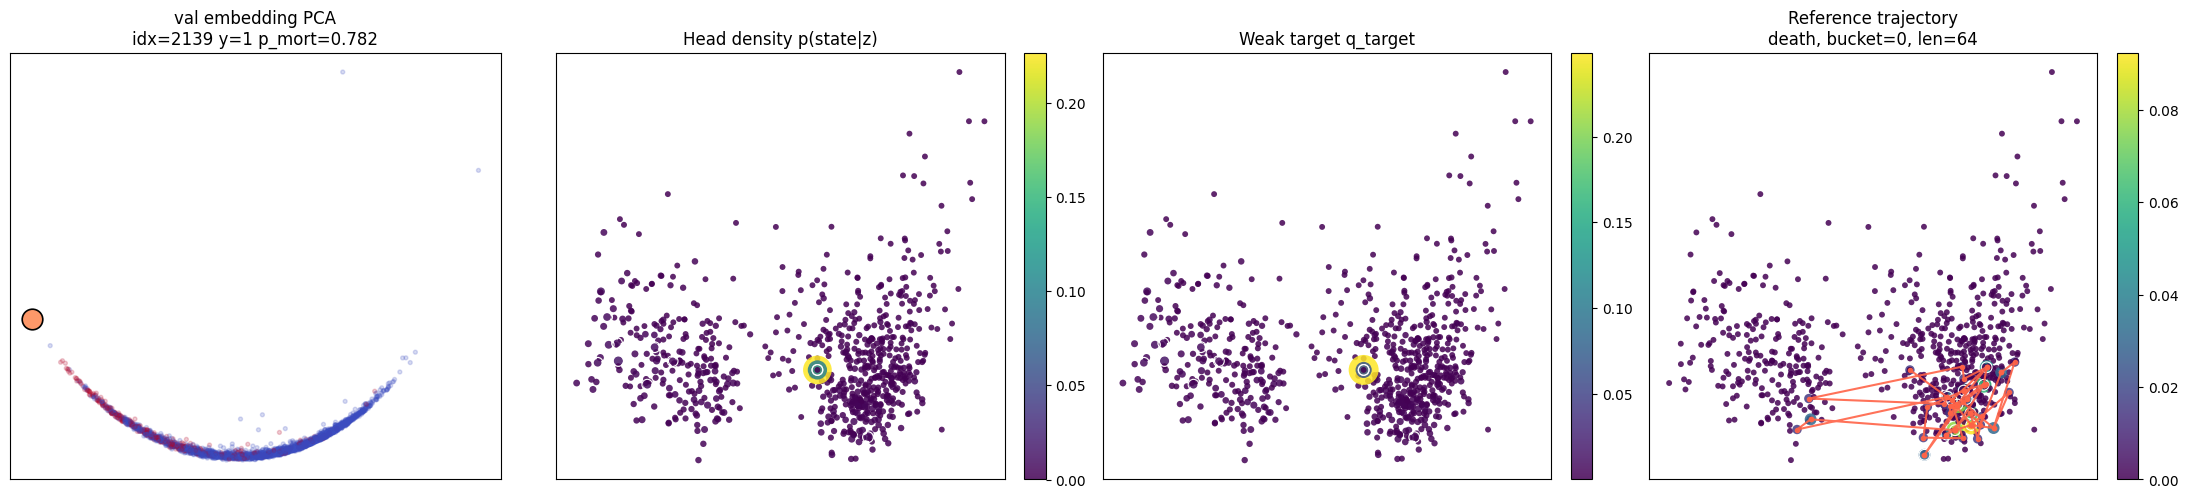


### TEST examples


,split,idx,mortality_label,coper_p_mortality,severity_bucket,pred_expected_sofa,target_entropy,pred_entropy,top_state_pred,top_state_sofa,reference_found,reference_terminal_state,reference_mean_sofa,reference_length
0,test,208,1,0.67115,0,3.614828,4.828547,4.898903,713,0.0,True,713,4.218156,64


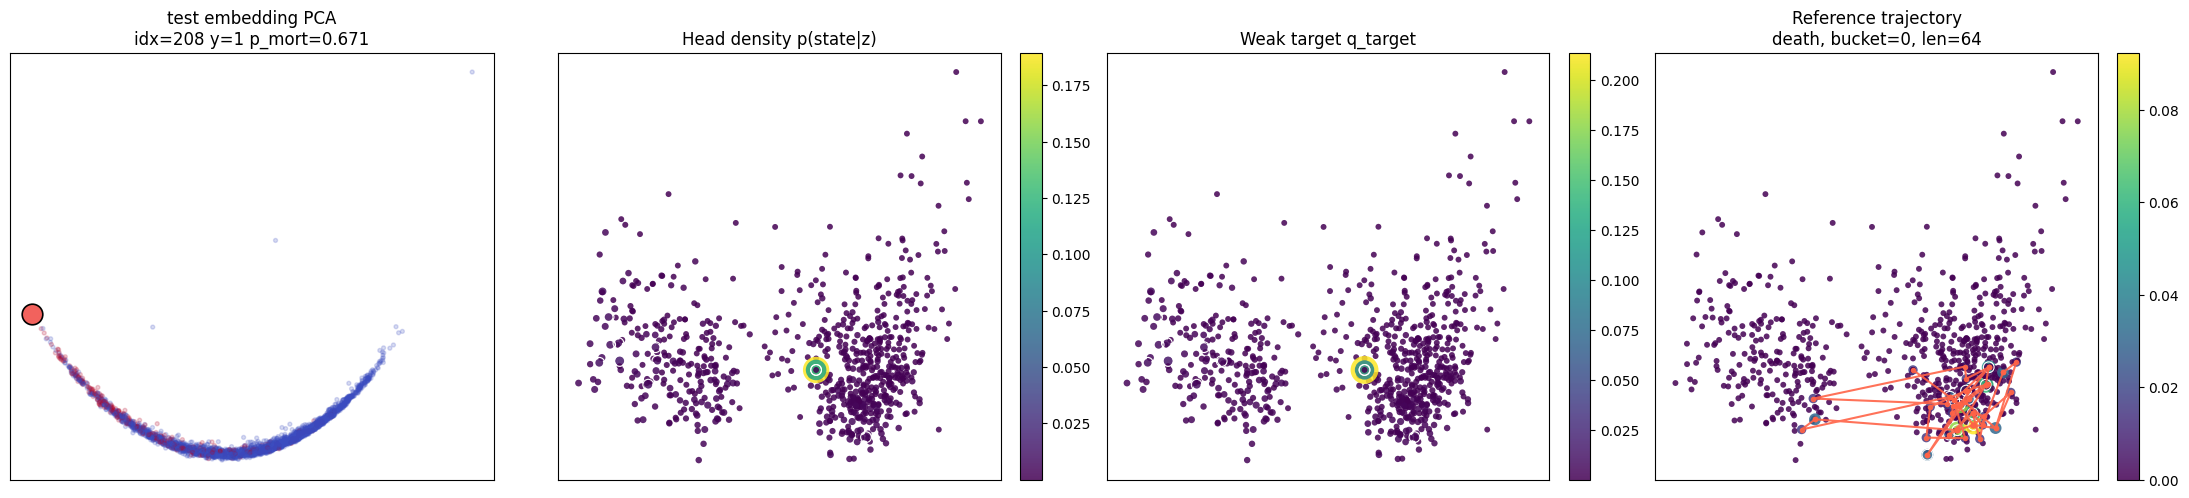

,split,idx,mortality_label,coper_p_mortality,severity_bucket,pred_expected_sofa,target_entropy,pred_entropy,top_state_pred,top_state_sofa,reference_found,reference_terminal_state,reference_mean_sofa,reference_length
0,test,1471,0,0.623813,0,3.657881,4.854944,4.955319,713,0.0,True,714,4.276856,31


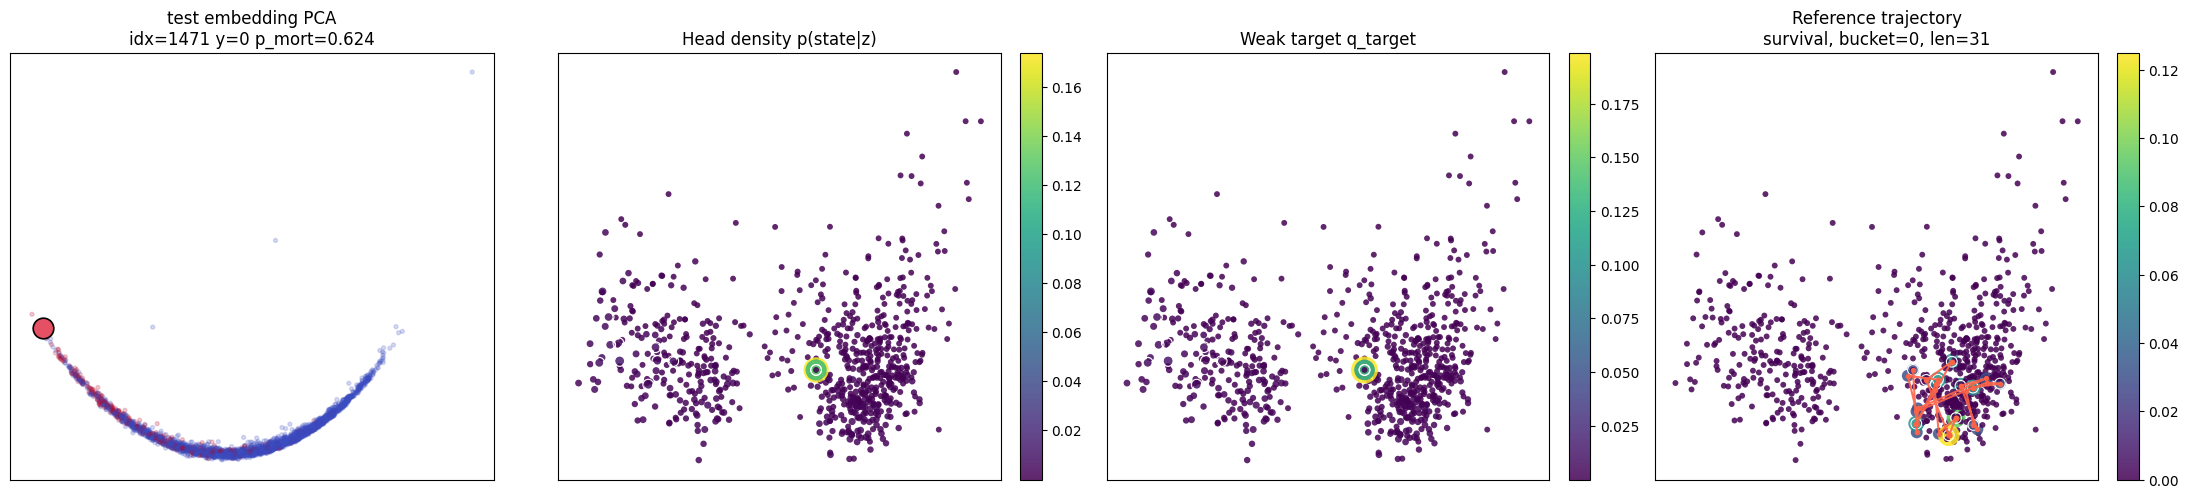

,split,idx,mortality_label,coper_p_mortality,severity_bucket,pred_expected_sofa,target_entropy,pred_entropy,top_state_pred,top_state_sofa,reference_found,reference_terminal_state,reference_mean_sofa,reference_length
0,test,1700,1,0.031185,2,6.743468,5.842731,5.834306,714,0.0,True,713,5.659306,43


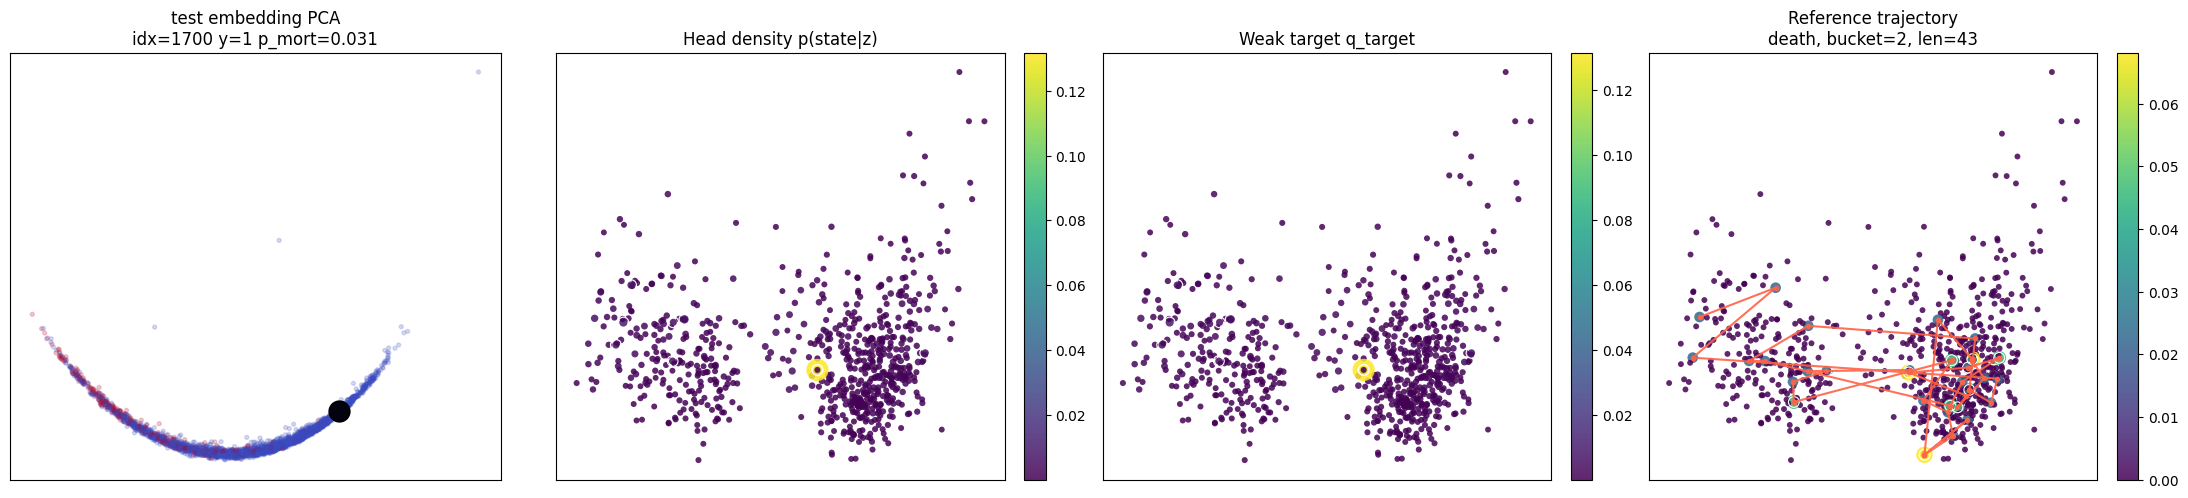

,split,idx,mortality_label,coper_p_mortality,severity_bucket,pred_expected_sofa,target_entropy,pred_entropy,top_state_pred,top_state_sofa,reference_found,reference_terminal_state,reference_mean_sofa,reference_length
0,test,3194,0,0.01933,2,6.826682,5.836332,5.871118,714,0.0,True,714,7.411487,24


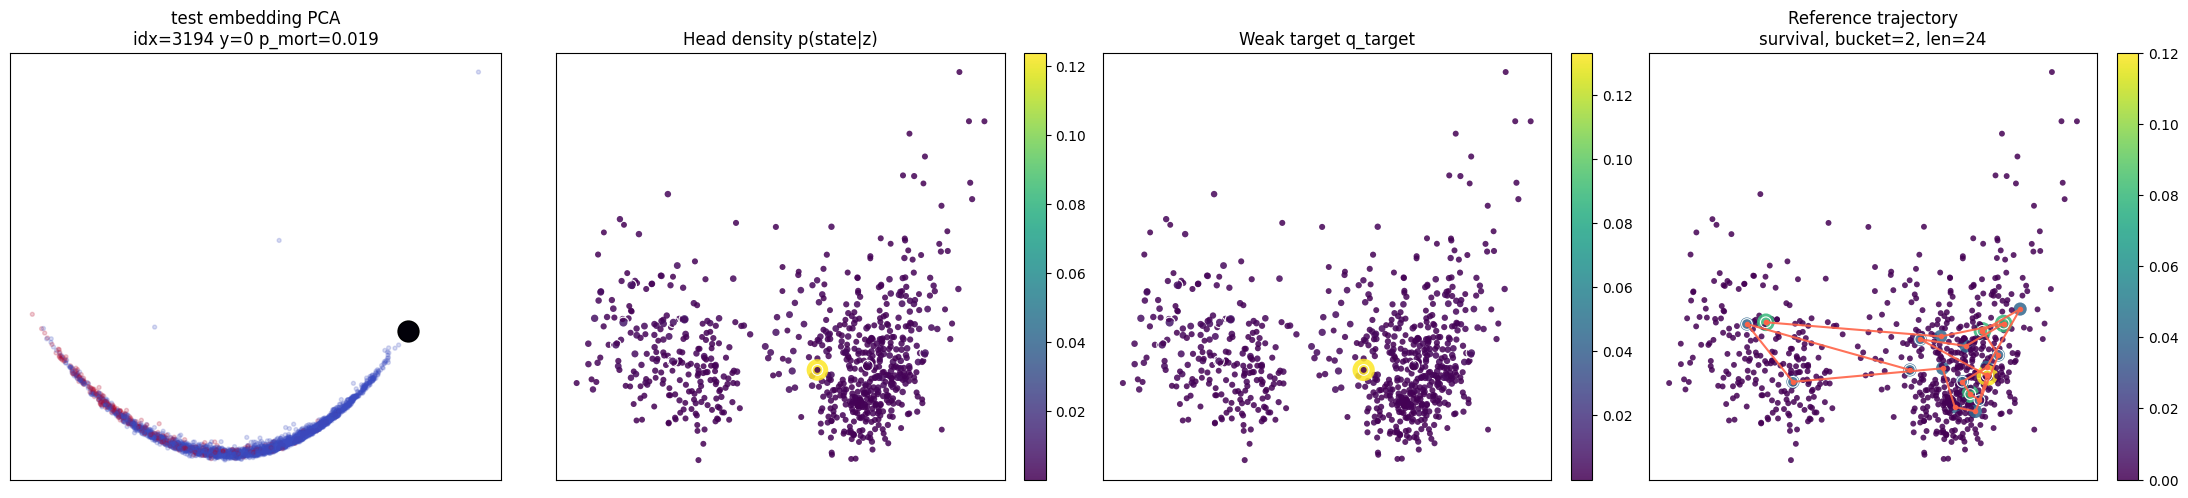

In [9]:
for split, idxs in examples.items():
    print(f"\n### {split.upper()} examples")
    for idx in idxs:
        _ = visualize_patient_mapping(split=split, idx=int(idx), compare_to="target")
        plt.show()